In [1]:
%load_ext autoreload

%autoreload 2

In [2]:
import numpy as np
import jax.numpy as jnp
import jax.scipy as jsp
import matplotlib.pyplot as plt

from jax import random, jit, value_and_grad
from jax import config
from scipy.optimize import minimize

config.update("jax_enable_x64", True)
%matplotlib inline

In [3]:
noise = 0.2
from jaxtyping import ArrayLike
from jax import Array
def func(X: ArrayLike)->Array:
    return np.sin(X)

# Noisy training data
X = np.arange(-3, 4, 1).reshape(-1, 1)
y = np.sin(X) + noise * np.random.randn(*X.shape)

X_test = np.arange(-5, 5, 0.2).reshape(-1, 1)
f_true = func(X_test)

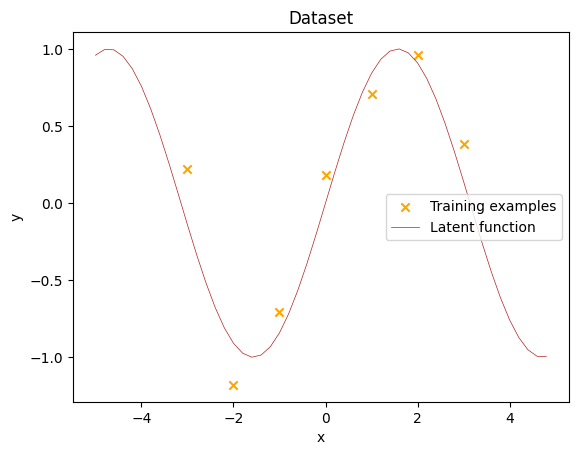

In [4]:
plt.scatter(X, y, label='Training examples', marker='x', color='orange')
plt.plot(X_test, f_true, label='Latent function', color='firebrick', lw=0.5)
plt.title('Dataset')
plt.xlabel('x')
plt.ylabel('y')
plt.legend();

In [5]:
from jax_mc_pilco.model_learning.gp.kernels.stationary import ExpSquared
from jax_mc_pilco.model_learning.gp.gaussian_process import gp_fit, GaussianProcess

In [6]:
params = {
    "kernel":
    {
        "coefficient": jnp.array(0.9,dtype=jnp.float64),
        "log_scale":jnp.array(0.,dtype=jnp.float64)
    },
    "mean":{},
    "likelihood": 
    {
        "log_diag":jnp.array(-0.5,dtype=jnp.float64)
    }
}

In [7]:
gp = GaussianProcess(ExpSquared,X,y,params)

In [8]:
gp = gp_fit(gp)

In [11]:
from jax_mc_pilco.model_learning.gp.kernels.base import softplus

In [12]:
kernel = gp.kernel(**gp.params["kernel"])
mean = gp.mean(**gp.params["mean"])

log_noise = gp.params["likelihood"]["log_diag"]
noise = softplus(log_noise)
sq_noise = jnp.square(noise)

In [13]:
L_xx, alpha = gp.cached_choleskys

K_tx = kernel(X_test, gp.X)
mu_t = mean(X_test)

In [14]:
K_tx.shape, mu_t.shape, L_xx.shape, alpha.shape

((50, 7), (50,), (7, 7), (7,))

In [17]:
y_t = mu_t + jnp.matmul(K_tx, alpha)

V = jsp.linalg.solve_triangular(L_xx, K_tx.T, lower=True)

y_cov = (
    kernel(X_test, X_test)
    - jnp.matmul(V.T, V)
    + gp.jitter(X_test.shape[0], value=sq_noise)
)

In [18]:
f_mu, f_cov = gp.predict(X_test)

ValueError: Invalid kernel diagonal shape: expected ndim = 1, got ndim=2 check the dimensions of parameters and custom kernels

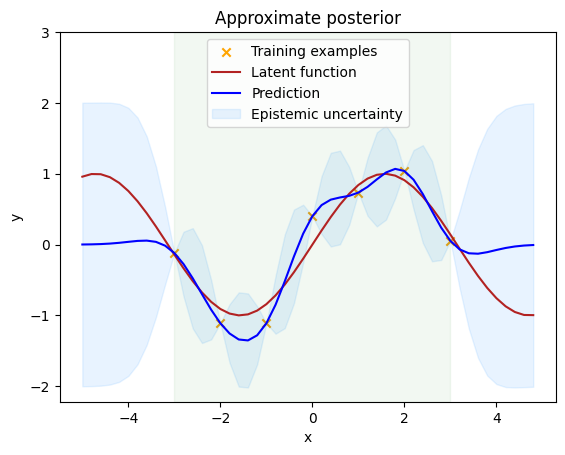

In [29]:
f_test_var = jnp.diag(f_cov)
f_test_std = jnp.sqrt(f_test_var)

plt.scatter(X, y, label='Training examples', marker='x', color='orange')
plt.plot(X_test, f_true, label='Latent function', c='firebrick', lw=1.5)

plt.plot(X_test, f_mu, label='Prediction', c='blue')
plt.fill_between(X_test.ravel(), 
                 f_mu.ravel() + 2 * f_test_std, 
                 f_mu.ravel() - 2 * f_test_std,
                 label='Epistemic uncertainty',
                 color='dodgerblue', alpha=0.1)
plt.title('Approximate posterior')
plt.xlabel('x')
plt.ylabel('y')
plt.ylim(None, 3.0)
plt.legend();
plt.axvspan(X.min(),X.max(),color='green',alpha=0.05);

In [30]:
gp.params

{'kernel': {'coefficient': Array(1.00216759, dtype=float64),
  'log_scale': Array(-0.07952584, dtype=float64)},
 'likelihood': {'log_diag': Array(-9.69663783, dtype=float64)},
 'mean': {}}